Parsed Data:
      Node  Block  ProductionTime_ms  StartDelay_ms
0    Alice   3032             3591.0           43.0
1    Alice   3037             3585.0           44.0
2    Alice   3042             3602.0           39.0
3    Alice   3047             3599.0           39.0
4    Alice   3052             3151.0           38.0
..     ...    ...                ...            ...
82  Oliver   3048             3638.0           42.0
83  Oliver   3053             3625.0           40.0
84  Oliver   3058             2682.0           46.0
85  Oliver   3067               41.0           40.0
86  Oliver   3077               38.0           67.0

[87 rows x 4 columns]


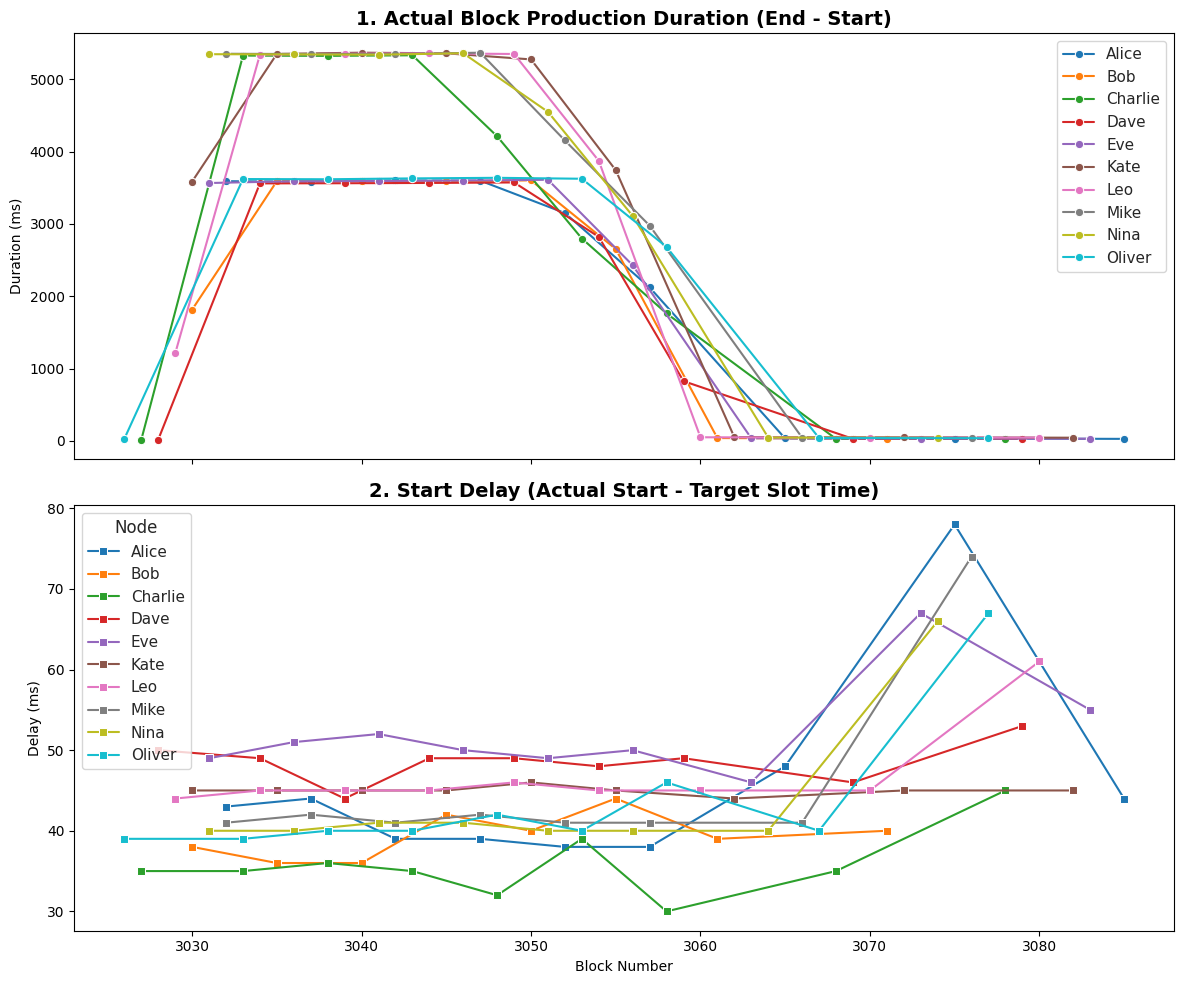

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import glob
import os

RELAYS = [
    "ferdie",
    "george",
    "henry",
    "iris",
    "jack",
    "paul",
    "quinn",
    "rita",
    "sam",
    "tom"
]

BLOCK_PRODUCERS = [
    "alice",
    "bob",
    "charlie",
    "dave",
    "eve",
    "kate",
    "leo",
    "mike",
    "nina",
    "oliver"
]


# ---------------------------------------------------------
# STEP 1: GET DATA
# ---------------------------------------------------------
logs_path = '/home/christos/shielded/jupyter/2026-01-14/all_logs/'
files_to_process = []
for node in BLOCK_PRODUCERS:
    files_to_process.append(logs_path+node+".txt")

# ---------------------------------------------------------
# STEP 2: PARSE THE LOGS
# ---------------------------------------------------------

def parse_substrate_logs(file_list):
    data = []
    
    # Regex to capture Timestamp and the Message
    # Example: 2026-01-14 03:34:24.044 ...
    base_pattern = re.compile(r"^(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})\s+(.*)")
    
    # Regex for specific events
    start_pattern = re.compile(r"Starting consensus session on top of parent")
    end_pattern = re.compile(r"Prepared block for proposing at (\d+)")

    for filename in file_list:
        node_name = os.path.splitext(os.path.basename(filename))[0].capitalize() # e.g., 'Alice'
        
        current_start_time = None
        
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                
                # Extract Timestamp
                match = base_pattern.search(line)
                if not match: continue
                
                timestamp_str = match.group(1)
                message = match.group(2)
                
                # Parse datetime object
                try:
                    current_time = datetime.strptime(timestamp_str, "%Y-%m-%d %H:%M:%S.%f")
                except ValueError:
                    continue # Skip malformed lines

                # 1. Detect START of block production
                if start_pattern.search(message):
                    current_start_time = current_time
                
                # 2. Detect END of block production
                elif end_pattern.search(message):
                    block_match = end_pattern.search(message)
                    block_num = int(block_match.group(1))
                    
                    if current_start_time:
                        # METRIC A: Actual Production Time (End - Start)
                        duration = (current_time - current_start_time).total_seconds() * 1000 # to ms
                        
                        # METRIC B: Start Delay (Start - Ideal Target)
                        # We assume target is the nearest 6-second interval rounded down
                        # e.g., 24.044 -> Target was 24.000. Delay = 44ms
                        # e.g., 24.900 -> Target was 24.000. Delay = 900ms
                        
                        # Calculate seconds past the minute
                        total_seconds = current_start_time.second + (current_start_time.microsecond / 1e6)
                        remainder = total_seconds % 6 
                        
                        # If remainder is small (e.g. 0.044), that's the delay. 
                        # If remainder is huge (e.g. 5.9), it might mean we are EARLY or extremely late, 
                        # but usually logs are slightly late. We assume positive delay.
                        start_delay_ms = remainder * 1000
                        
                        data.append({
                            "Node": node_name,
                            "Block": block_num,
                            "ProductionTime_ms": duration,
                            "StartDelay_ms": start_delay_ms
                        })
                        
                        # Reset start time for next block
                        current_start_time = None

    return pd.DataFrame(data)

# Run the parser on our generated files
df = parse_substrate_logs(files_to_process)

print("Parsed Data:")
print(df)

# ---------------------------------------------------------
# STEP 3: PLOT THE GRAPHS
# ---------------------------------------------------------

if not df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    sns.set_theme(style="whitegrid")

    # GRAPH 1: Production Time (Duration)
    # How long did the CPU actually churn to build the block?
    sns.lineplot(
        ax=axes[0],
        data=df, 
        x="Block", 
        y="ProductionTime_ms", 
        hue="Node", 
        marker="o",
        palette="tab10"
    )
    axes[0].set_title("1. Actual Block Production Duration (End - Start)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Duration (ms)")
    axes[0].legend(loc='upper right')

    # GRAPH 2: Start Delay
    # How long after the ideal 6s slot did the node start working?
    sns.lineplot(
        ax=axes[1],
        data=df, 
        x="Block", 
        y="StartDelay_ms", 
        hue="Node", 
        marker="s", # Square marker to distinguish
        palette="tab10"
    )
    axes[1].set_title("2. Start Delay (Actual Start - Target Slot Time)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Delay (ms)")
    axes[1].set_xlabel("Block Number")
    
    # Force Integer X-Axis
    if len(df) < 20:
        axes[1].set_xticks(sorted(df['Block'].unique()))

    plt.tight_layout()
    plt.savefig("block_timing_analysis.png")
    plt.show()
else:
    print("No matching log lines found. Check regex patterns.")

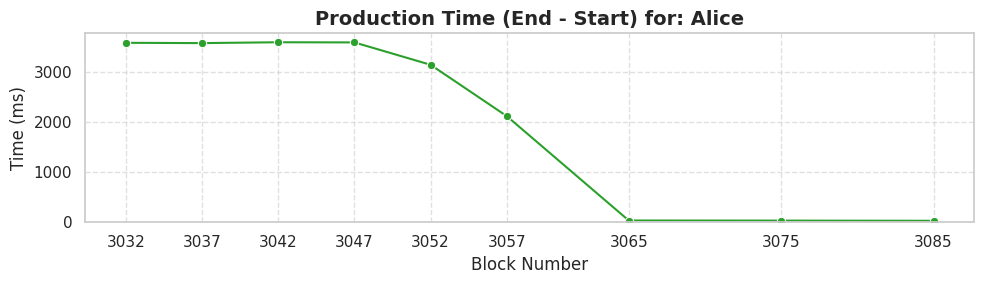

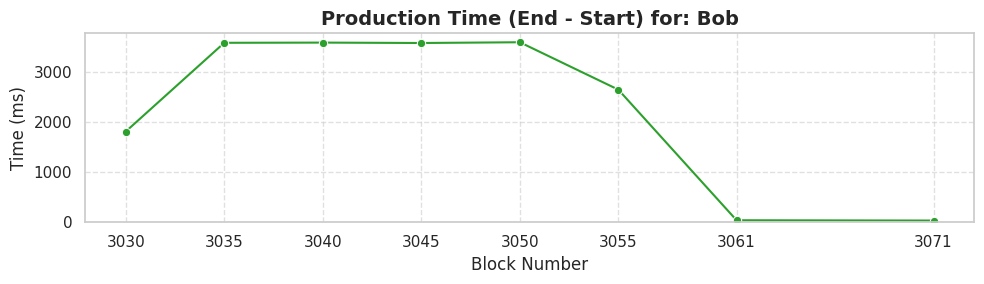

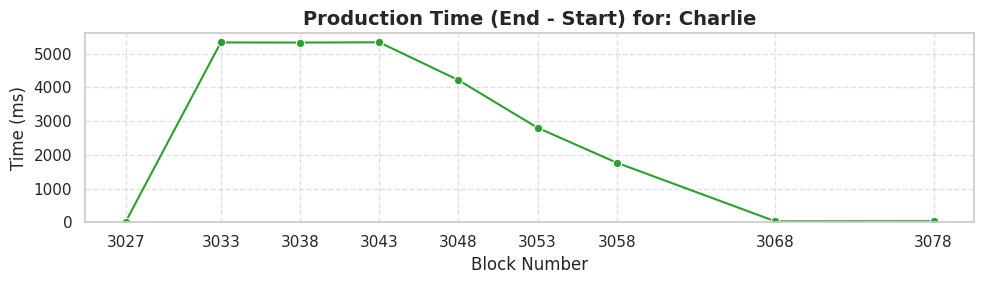

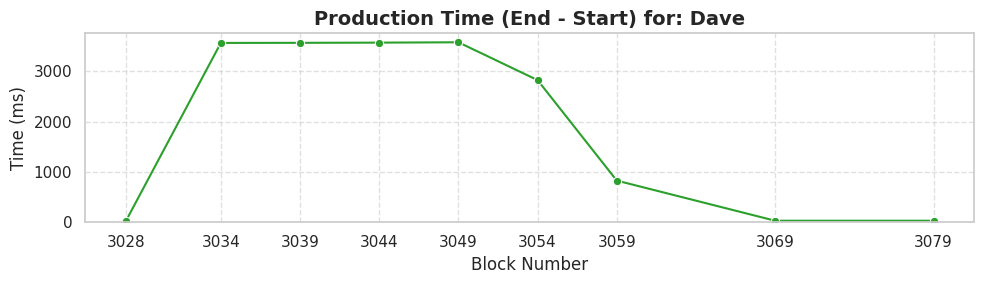

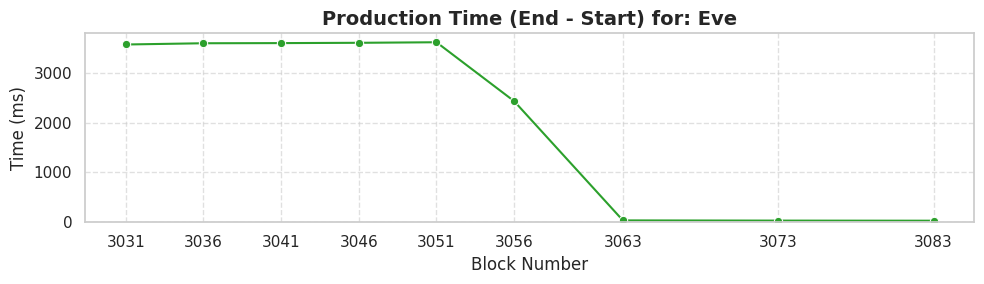

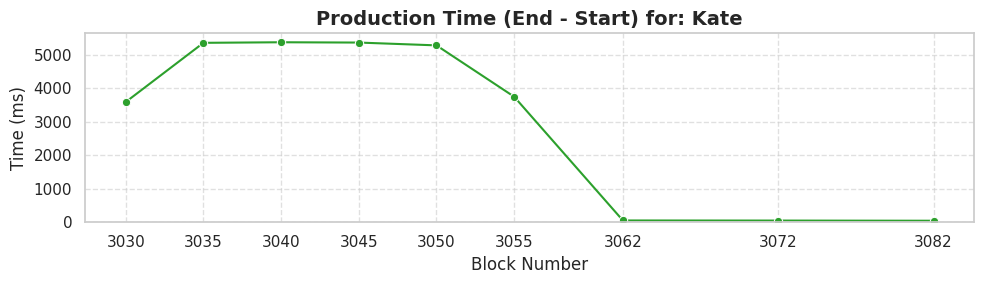

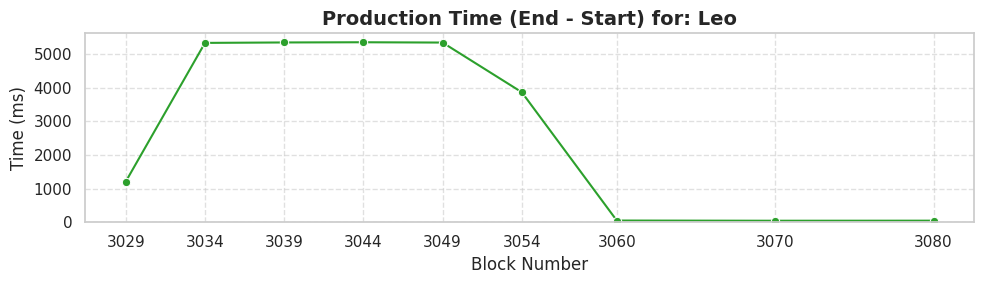

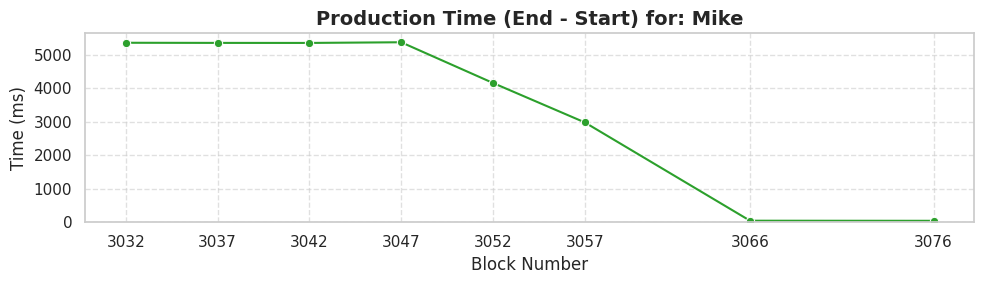

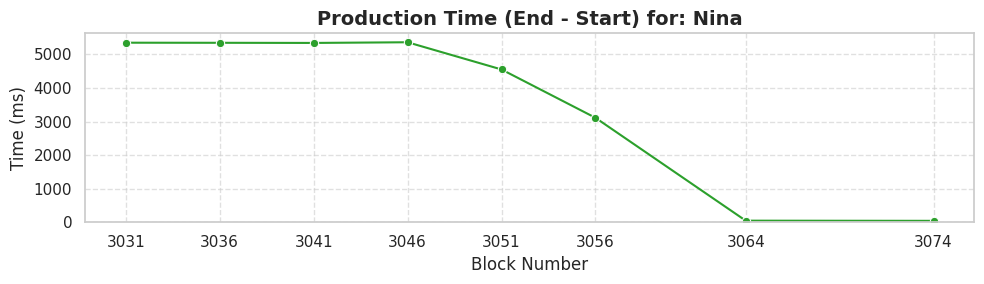

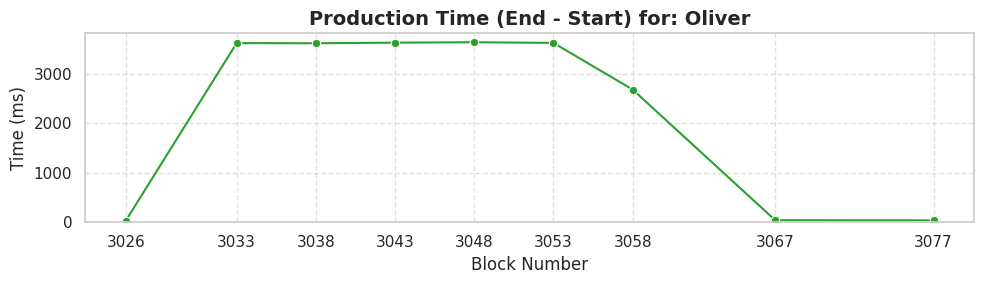

In [7]:
# 1. Get the list of nodes
unique_nodes = sorted(df['Node'].unique())

# 2. Iterate and plot
for node in unique_nodes:
    # Filter data for this specific node
    node_data = df[df['Node'] == node]
    
    # Skip if no data for this node
    if node_data.empty:
        continue

    # Create a new figure for each node
    plt.figure(figsize=(10, 3))
    
    # Plot Production Time (End - Start)
    sns.lineplot(
        data=node_data, 
        x="Block", 
        y="ProductionTime_ms", 
        marker="o", 
        color="#2ca02c"  # Green color to distinguish from previous graphs
    )
    
    # Formatting
    plt.title(f"Production Time (End - Start) for: {node}", fontsize=14, fontweight='bold')
    plt.ylabel("Time (ms)")
    plt.xlabel("Block Number")
    
    # Ensure Y-axis starts at 0 for accurate scale
    plt.ylim(bottom=0)
    
    # Force integer ticks on X-axis if range is small
    if len(node_data) < 50:
        plt.xticks(node_data["Block"].unique())
        
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()